In [3]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom

print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")


NOTEBOOK_NAME = "ARK_profiles.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        self.gis = os.path.normpath(os.path.join(self.data, 'Geotiff'))
        
dirs = Dirs()

print("Project directory namespace:")
descr(dirs)


raai_colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green    
]

leg_colors = [
    "#0000FF",  # blue
    "#FF0000",  # red
    "#00FF00",  # green
    "#000033",  # dark navy
    "#FF00B6",  # magenta
    "#005300",  # dark green
    "#FFD300",  # yellow
    "#009FFF",  # sky blue
    "#9A4D42",  # brown
    "#00FFBE",  # turquoise
    "#783FC1",  # purple
    "#1F9698",  # teal
    "#FFACFD",  # light pink
    "#B1CC71",  # olive
    "#F1085C",  # crimson
    "#FE8F42",  # orange
    "#DD00FF",  # violet
    "#201A01",  # dark brown
    "#720055",  # dark magenta
    "#766C95"   # slate gray
]


=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable:  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
sys.path:
/Users/Theo/GRWMODELS/python/tools
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__
NOTEBOOK_NAME = 'ARK_profiles.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images

/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r01_478940_2013.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r01_478940_2025.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r02_477260_2013.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r02_477260_2025.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r03_475910_2013.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r03_475910_2025.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r04_475500_2013.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r04_475500_2025.csv
/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/Geotiff/ARKprof_r05_475100_2013.csv
/Users/Theo/Development/python/mf6_tools/mf6la

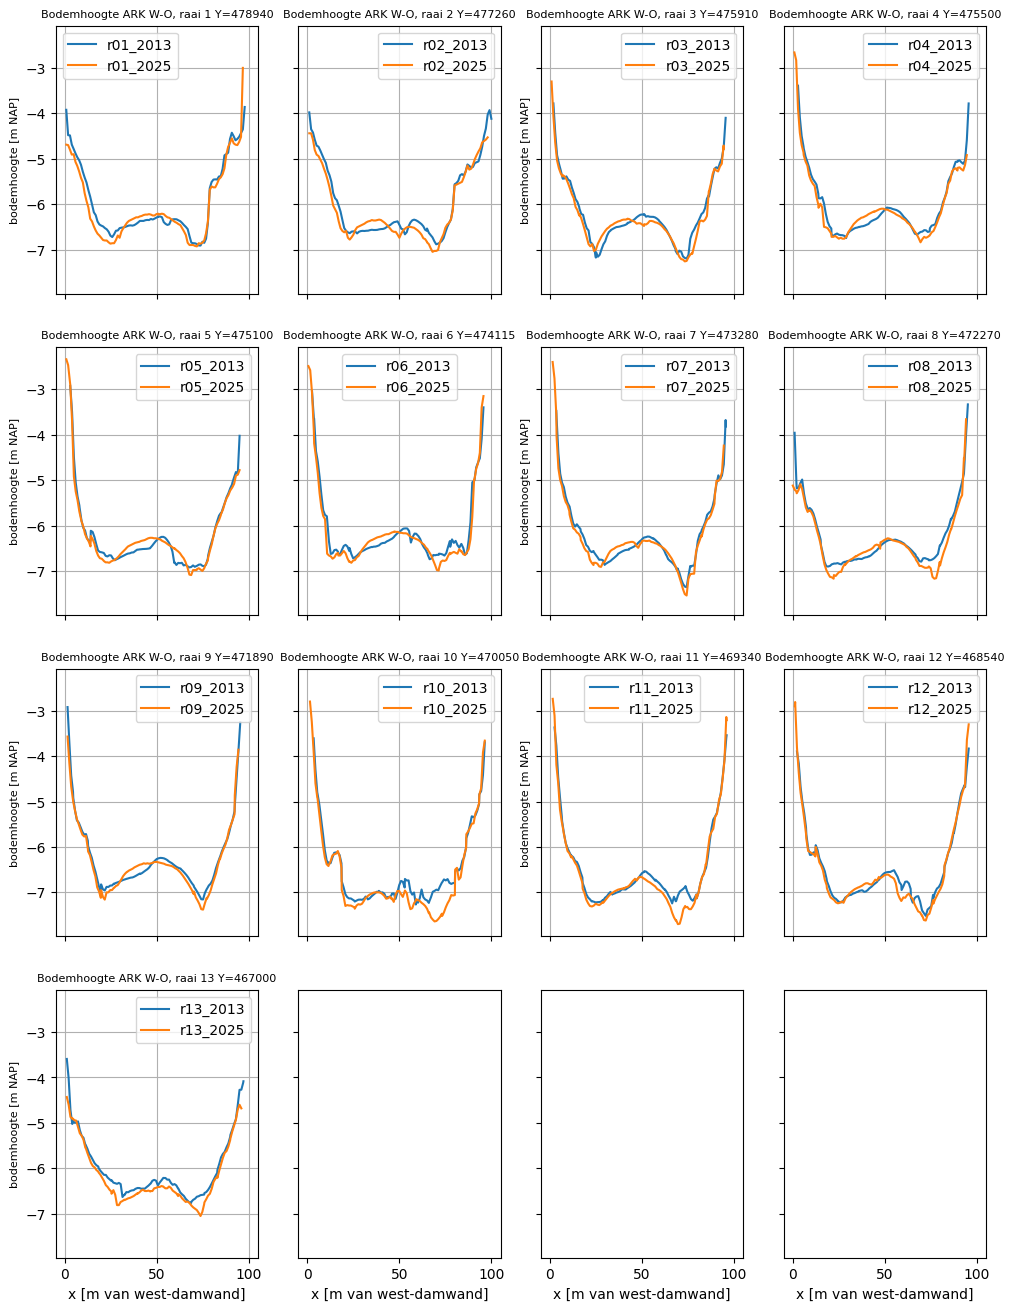

In [4]:
# ARK profiles

csv_files = sorted(glob(os.path.join(dirs.gis, 'ARKprof*.csv')))
print('\n'.join(csv_files))

profiles = {}
for fname in csv_files:
    bname = os.path.basename(fname)
    m = re.match(r"ARKprof_r(\d{2})_(\d{6})_(\d{4})\.csv", bname)
    if m:
        raai = int(m.group(1))
        Y    = int(m.group(2))
        year = int(m.group(3))
    else:
        raise ValueError(f"imporper file name\n{fname}")
    key = f"r{raai:02d}_{year}"
    profiles[key] = pd.read_csv(fname)
    profiles[key]['year']=year
    profiles[key]['Y']=Y
    prof_layer = profiles[key].loc[0, 'layer'][:4]
    print(f"prof_layer={prof_layer}, year={year}")

nrow, ncol = 4, 4
fig, axs = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(12, 16))


for i, (key, prof) in enumerate(profiles.items()):    
    raai = int(key[1:3])
    year = int(key[-4:])
    Y = float(prof.loc[0, 'Y'])
    try:
        ax = axs.ravel()[i // 2]
        if i % 2 == 0:
            ax.set_title(f"Bodemhoogte ARK W-O, raai {raai} Y={Y:.0f}", fontsize=8)
            ax.grid(True)
    except Exception:
        pass

    ax.plot(prof['distance'], prof['elevation'], label=key)
    if i % ncol == 0:
        ax.set_ylabel('bodemhoogte [m NAP]', fontsize=8)
    if i % 2 == 1:
        ax.legend()
for i in range((nrow - 1) * ncol, nrow * ncol):
    ax = axs.ravel()[i]
    ax.set_xlabel('x [m van west-damwand]')
    
plt.show()



fig saved to </Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/ARK_profiles_1_2_3.pdf>
fig saved to </Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/ARK_profiles_4_5_6.pdf>
fig saved to </Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/ARK_profiles_7_8_9.pdf>
fig saved to </Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/ARK_profiles_10_11_12.pdf>
fig saved to </Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/ARK_profiles_13.pdf>


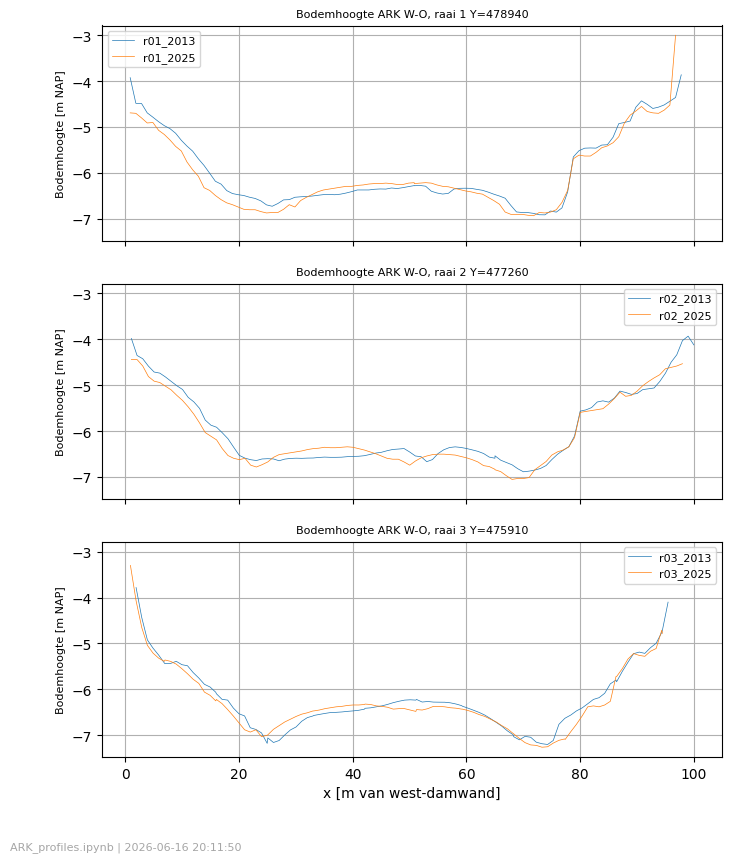

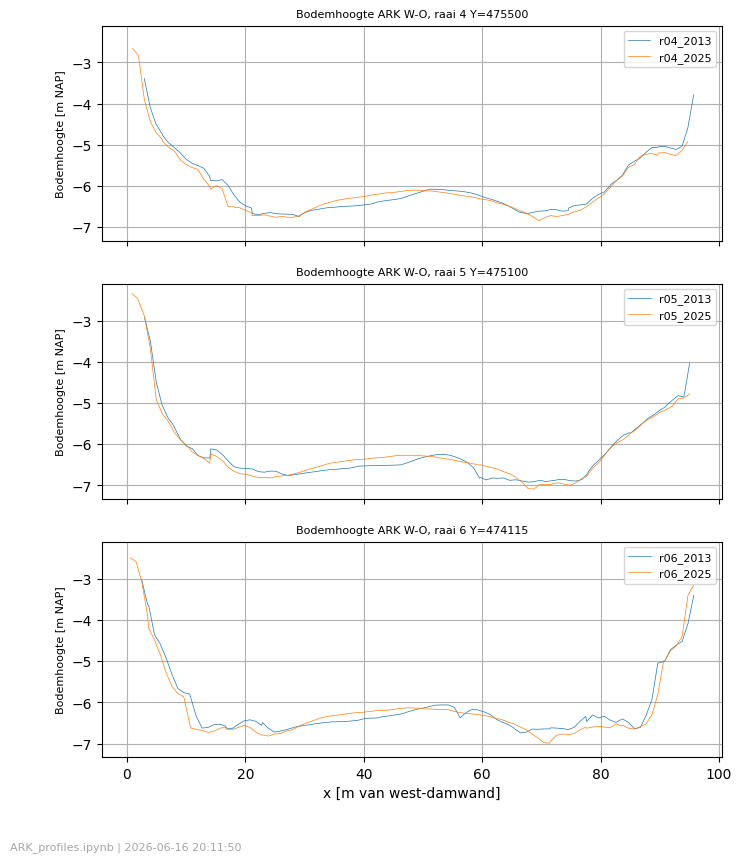

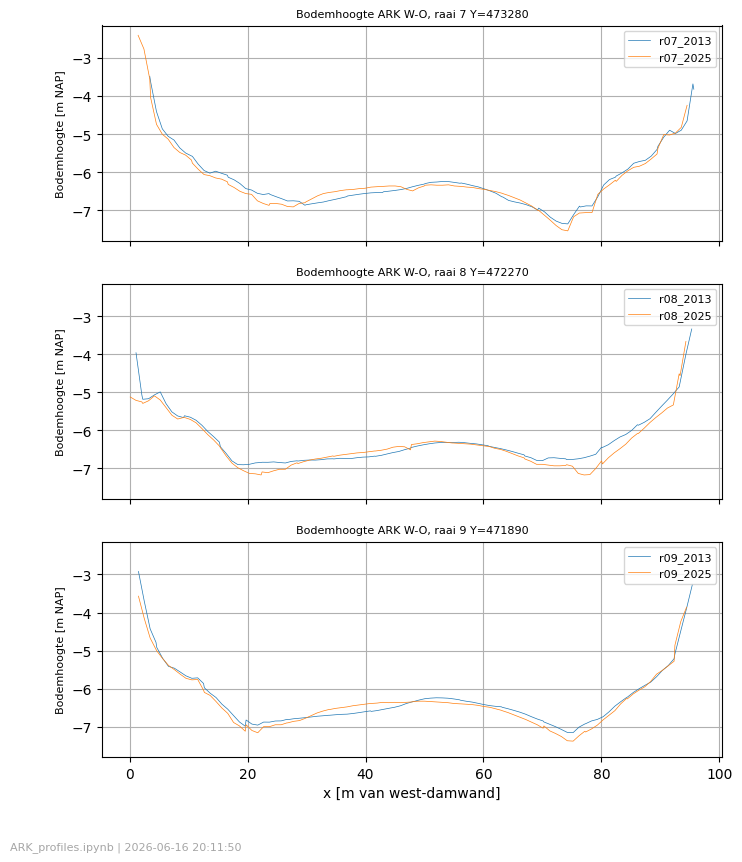

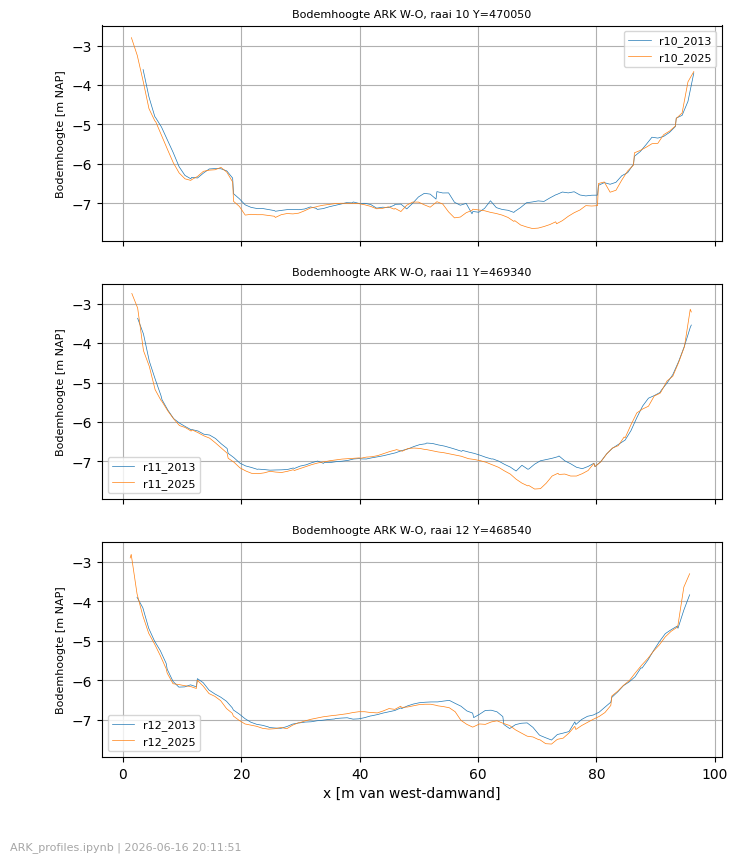

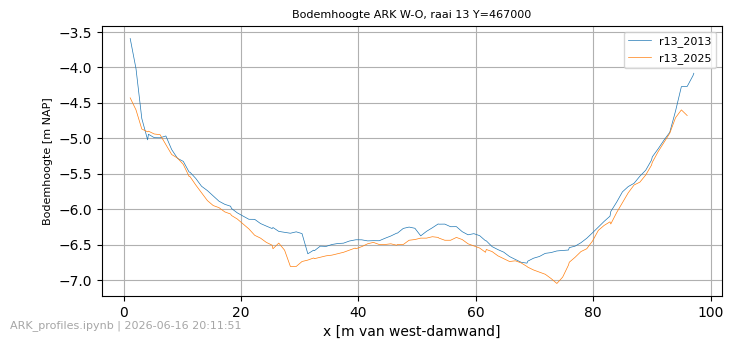

In [12]:
nrow = 3
figs = []

# --- Run over all keys (raaien, each raai has two profiles (2013 and 2025))
keys = list(profiles.keys())

for i, key in enumerate(keys):

    prof = profiles[key]

    # --- Per nrow profiles use a new figure    
    if i % (2 * nrow) == 0:
        # --- Prevent empty figs at the end
        n = len(keys) // 2 - len(figs) * nrow
        n = min(n, nrow)        
        fig, axs = plt.subplots(n, sharex='all', sharey='all', figsize=(8, n * 3 + 0.5))

        logo(fig, NOTEBOOK_NAME)
        figs.append(fig)        
        ia = 0
        raaien = []
  
    # if verbose:  
    #   print(f"i(key)={i}, ia={ia}")
    if isinstance(axs, plt.Axes):
        # --- Capture case of only one figure, the not an array of axs
        ax = axs
    else:
        ax = axs[ia]
        
    # --- Specifices of profile
    raai = int(key[1:3])
    year = int(key[-4:])
    Y = float(prof.loc[0, 'Y']) # Y coordinates of center line of ARK
    raaien.append(raai)
    
    # --- Distance in m from west-sheet piling
    ax.plot(prof['distance'], prof['elevation'], lw=0.5, label=key)

    # --- Fishish each fig    
    if i % 2 == 1:        
         ax.set_title(f"Bodemhoogte ARK W-O, raai {raai} Y={Y:.0f}", fontsize=8)
         ax.set_ylabel('Bodemhoogte [m NAP]', fontsize=8)
         ax.grid('both')
         ax.legend(fontsize=8)     
    if i % 2 == 1:
        ia += 1
        # ---Don't forget xlabel on last fig with fewer axes
        if ia % n == 0:
            ax.set_xlabel('x [m van west-damwand]')
            fname = f"ARK_profiles_{'_'.join([f'{r}' for r in np.unique(raaien)])}.pdf"
            path = os.path.join(dirs.images, fname)
            fig.savefig(path)
            print(f"fig saved to <{path}>")            
    
plt.show()


True

In [20]:
profiles

{'r01_2013':                                            layer   distance  elevation  year  \
 0    2025_1_973a865a_28a1_48da_b369_9e6cf4807130   0.000000        NaN  2013   
 1    2025_1_973a865a_28a1_48da_b369_9e6cf4807130   0.710613     -4.620  2013   
 2    2025_1_973a865a_28a1_48da_b369_9e6cf4807130   1.710603     -4.670  2013   
 3    2025_1_973a865a_28a1_48da_b369_9e6cf4807130   2.710593     -4.730  2013   
 4    2025_1_973a865a_28a1_48da_b369_9e6cf4807130   3.710583     -4.850  2013   
 ..                                           ...        ...        ...   ...   
 197  2013_1_f2bc68d7_880a_4a91_933a_1ea2aaffdd4e  95.709679     -4.211  2013   
 198  2013_1_f2bc68d7_880a_4a91_933a_1ea2aaffdd4e  96.709669     -4.061  2013   
 199  2013_1_f2bc68d7_880a_4a91_933a_1ea2aaffdd4e  97.709659     -3.826  2013   
 200  2013_1_f2bc68d7_880a_4a91_933a_1ea2aaffdd4e  98.709649        NaN  2013   
 201  2013_1_f2bc68d7_880a_4a91_933a_1ea2aaffdd4e  99.709640        NaN  2013   
 
           Y  